In [1]:
from IPython.display import HTML, display

display(HTML('''
<div style="
    display:flex;
    justify-content: center;
    align-items: center;
    flex-direction:column;
    text-align: center;
    margin-top:10px;
    margin-bottom:10px;
    ">
<div style="
    padding:30px 40px;
    border-radius:20px;
    backdrop-filter:blur(6px);
    background:rgba(255,255,255,0.08);
    border:1px solid rgba(255, 255, 255, 0.12);
    box-shadow: 0 8px 30px rgba(0,0,0,0.25);
    max-width:700px
">
<h1 style="
    font-family:'Inter', system-ui, sans-serif;
    font-size: 50px;
    font-weight:800;
    background:linear-gradient(80deg,#7b2ff7,#ff6fd8);
    -webkit-background-clip:text;
    background-clip:text;
    color:transparent;
    text-shadow: 0 25px 10px rgba(123,45,67,0.2)
    letter-spacing:-1px;
    margin:0px;
">
Top 500 Twitch Streamers
</h1>
</div>
</div>

'''))

**In this Kaggle Notebook, I analyzed data from the Top 500 Twitch Streamers based on 2024 statistics. The goal of this machine-learning project estimate future average viewer numbers for top Twitch streamers. Using average stream duration, total followers, followers gain per stream, total views, and other notable numerical category in the dataset.**



### ***Importing Libraries***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from tabulate import tabulate #to make a clean table for the data.

### ***Load Dataset***

In [3]:
df = pd.read_csv("/kaggle/input/streamers-dataset/datasetV2.csv")

print("Dataset Preview:")
df.head(500) #to show all the data below


Dataset Preview:


,RANK,NAME,LANGUAGE,TYPE,MOST_STREAMED_GAME,2ND_MOST_STREAMED_GAME,AVERAGE_STREAM_DURATION,FOLLOWERS_GAINED_PER_STREAM,AVG_VIEWERS_PER_STREAM,AVG_GAMES_PER_STREAM,TOTAL_TIME_STREAMED,TOTAL_FOLLOWERS,TOTAL_VIEWS,TOTAL_GAMES_STREAMED,ACTIVE_DAYS_PER_WEEK,MOST_ACTIVE_DAY,DAY_WITH_MOST_FOLLOWERS_GAINED
0,1,kaicenat,English,personality,Just Chatting,I'm Only Sleeping,7.6,18405,15852,2.3,4698,10600000,9150000,194,3.6,Friday,Saturday
1,2,jynxzi,English,personality,Tom Clancy's Rainbow Six Siege,NBA 2K20,5.4,3386,1145,1.2,8407,5760000,1950000,54,5.6,Tuesday,Sunday
2,3,caedrel,English,personality,League of Legends,I'm Only Sleeping,6.3,689,12331,1.3,6728,797000,14200000,111,2.8,Thursday,Sunday
3,4,caseoh_,English,personality,NBA 2K23,Just Chatting,4.6,7185,0,3.6,2554,4220000,53,385,6.2,Friday,Monday
4,5,ibai,Spanish,personality,Just Chatting,League of Legends,4.1,8289,190714,1.5,6865,15600000,359000000,149,4.3,Wednesday,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,497,gssspotted,Thai,personality,Dota 2,Just Chatting,6.2,3440,4736,2.0,5347,310000,4270000,181,2.5,Tuesday,Sunday
496,498,dogdog,English,personality,Hearthstone,Teamfight Tactics,5.6,2320,30305,1.3,11781,642000,70600000,99,5.3,Wednesday,Sunday
497,499,kyootbot,English,personality,Just Chatting,IRL,5.1,9180,13147,1.2,3152,563000,8060000,24,1.8,Sunday,Wednesday
498,500,lxrygirltv,Russian,personality,Casino,NaN,4.1,20,0,1.0,80,10500,0,1,1.6,Saturday,Saturday


### ***Dataset Info***

In [4]:
print("\n Dataset Information")
print(tabulate([[df.shape[0], df.shape[1], df.isnull().sum().sum()]],
headers=["Total Rows", "Total Column", "Missing Values"], tablefmt='grid'))

df = df.dropna()


 Dataset Information
+--------------+----------------+------------------+
|   Total Rows |   Total Column |   Missing Values |
+==============+================+==================+
|          500 |             17 |               27 |
+--------------+----------------+------------------+


### ***Categorical Variables***

In [5]:
label_cols = ["LANGUAGE","TYPE", "MOST_STREAMED_GAME"]
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

features = [
    "AVERAGE_STREAM_DURATION",
    "FOLLOWERS_GAINED_PER_STREAM",
    "TOTAL_FOLLOWERS",
    "TOTAL_VIEWS",
    "ACTIVE_DAYS_PER_WEEK",
    "TOTAL_TIME_STREAMED",
    
]

target = "AVG_VIEWERS_PER_STREAM"

x = df[features]
y = df[target]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


### ***Train and Test Split*** 

In [6]:
# Train
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(x_train, y_train)

# Prediction
y_pred = model.predict(x_test)

### ***Evaluation***

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
train_r2= model.score(x_train, y_train)
test_r2 = model.score(x_test, y_test)
accuracy = r2 * 100

metric = [
    ["Mean Absolute Error (MAE)", round(mae,2)],
    ["Mean Squared Error (MSE)", round(mse,2)],
    ["Root Mean Squared Error (RMSE)", round(rmse,2)],
    ["R2 Score (Test)", round(r2,3)],
    ["R2 Score (Train)", round(train_r2,3)],
    ["Model Accuracy (R2%)", round(accuracy, 2)]  
]

print("Model Evaluation:")
print(tabulate(metric, headers=["Metric", "Value"], tablefmt="fancy_grid"))

Model Evaluation:
╒════════════════════════════════╤═════════════════╕
│ Metric                         │           Value │
╞════════════════════════════════╪═════════════════╡
│ Mean Absolute Error (MAE)      │ 13980.2         │
├────────────────────────────────┼─────────────────┤
│ Mean Squared Error (MSE)       │     5.44852e+08 │
├────────────────────────────────┼─────────────────┤
│ Root Mean Squared Error (RMSE) │ 23342.1         │
├────────────────────────────────┼─────────────────┤
│ R2 Score (Test)                │    -0.388       │
├────────────────────────────────┼─────────────────┤
│ R2 Score (Train)               │     0.387       │
├────────────────────────────────┼─────────────────┤
│ Model Accuracy (R2%)           │   -38.82        │
╘════════════════════════════════╧═════════════════╛


### ***Visualizations***

Actual vs Predicted:


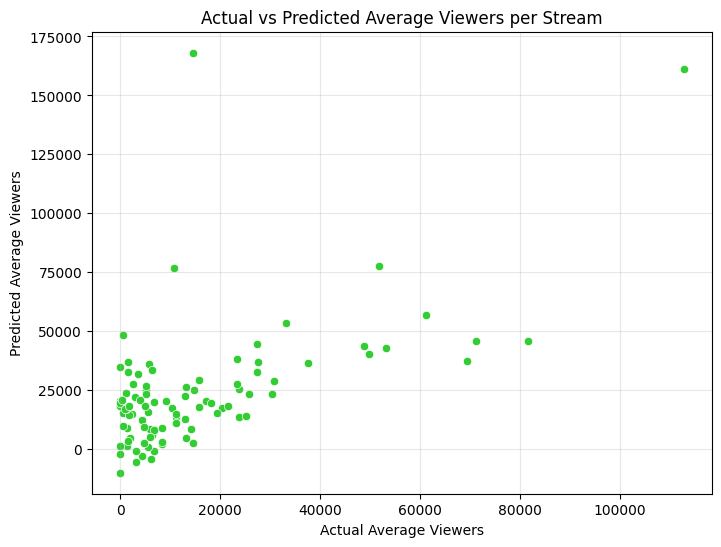

In [8]:
print("Actual vs Predicted:")

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color="#32CD32")
plt.xlabel("Actual Average Viewers")
plt.ylabel("Predicted Average Viewers")
plt.title("Actual vs Predicted Average Viewers per Stream")
plt.grid(True, alpha=0.3)
plt.show()


Residual Distribution:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


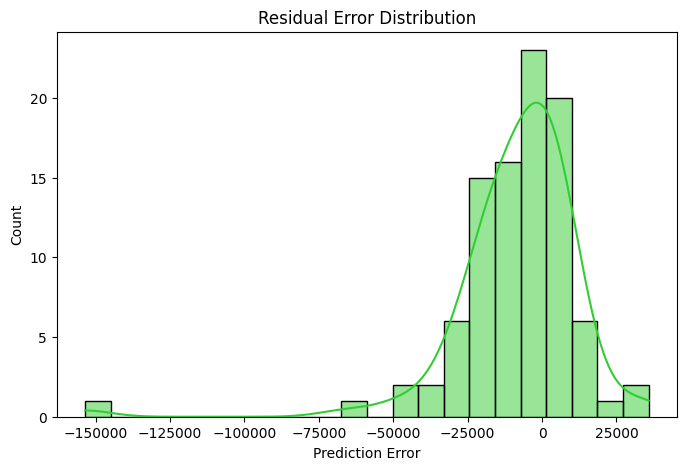

In [9]:
print("Residual Distribution:")

plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, kde=True, color="#32CD32")
plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

Correlation Heatmap:


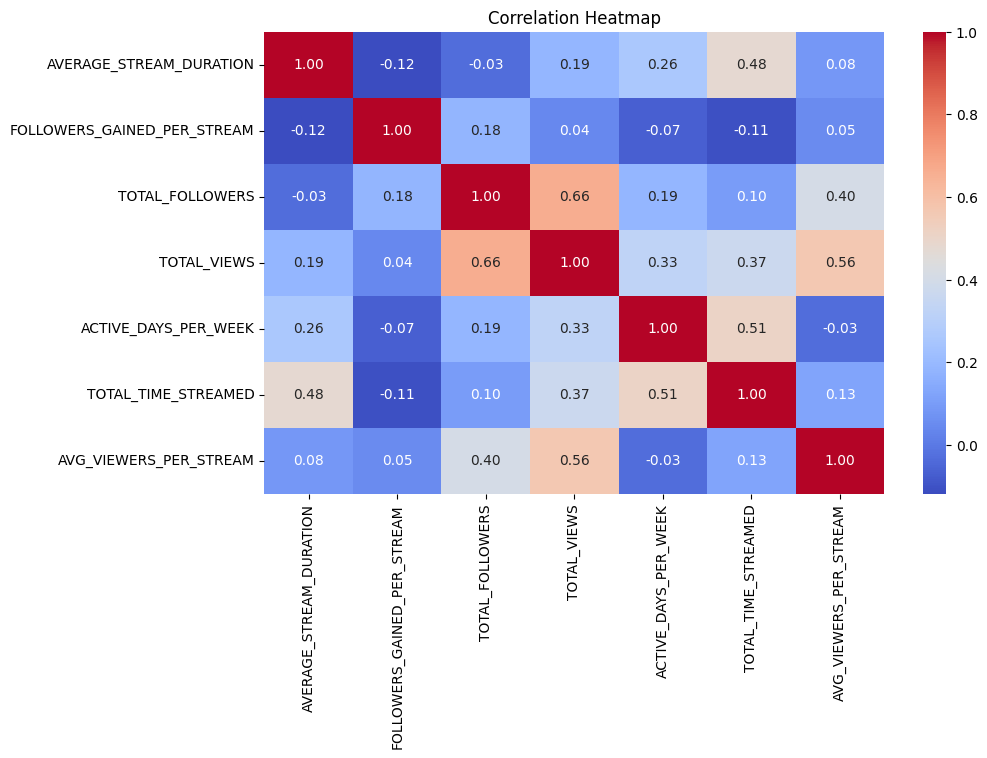

In [10]:
print("Correlation Heatmap:")

plt.figure(figsize=(10,6))
corr = df[features + [target]].corr()
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Feature Importance:
+-----------------------------+---------------+
| Feature                     |   Coefficient |
+=============================+===============+
| TOTAL_VIEWS                 |     32353.6   |
+-----------------------------+---------------+
| TOTAL_FOLLOWERS             |      2821.57  |
+-----------------------------+---------------+
| AVERAGE_STREAM_DURATION     |      1778.34  |
+-----------------------------+---------------+
| TOTAL_TIME_STREAMED         |       977.961 |
+-----------------------------+---------------+
| FOLLOWERS_GAINED_PER_STREAM |       117.981 |
+-----------------------------+---------------+
| ACTIVE_DAYS_PER_WEEK        |    -14249.5   |
+-----------------------------+---------------+


<function matplotlib.pyplot.show(close=None, block=None)>

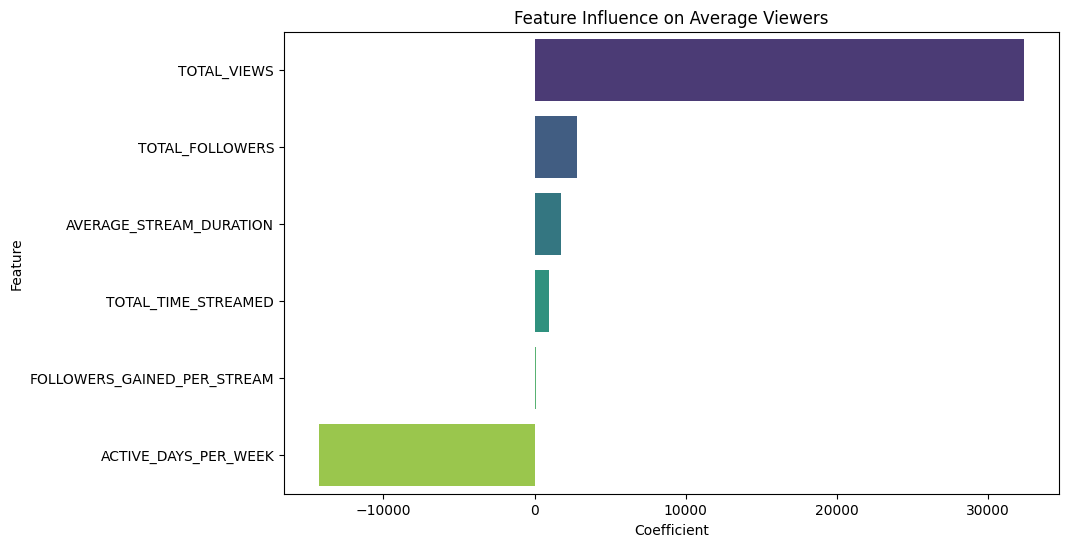

In [11]:
print("Feature Importance:")

importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(tabulate(importance, headers="keys", tablefmt="grid", showindex=False))

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=importance, palette="viridis")
plt.title("Feature Influence on Average Viewers")
plt.show


### ***Full Prediction***

In [12]:
pred_table = pd.DataFrame({
    "Streamer": df.loc[y_test.index]["NAME"].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

pred_table["% Change"] = ((pred_table["Predicted"] - pred_table["Actual"]) / pred_table["Actual"]) * 100
print ("Sample Prediction with % Change:")
print(tabulate(pred_table.head(10), headers="keys", tablefmt="rounded_grid", showindex=False))


Sample Prediction with % Change:
╭────────────┬──────────┬─────────────┬────────────╮
│ Streamer   │   Actual │   Predicted │   % Change │
├────────────┼──────────┼─────────────┼────────────┤
│ mizkif     │    71268 │    45629.6  │   -35.9746 │
├────────────┼──────────┼─────────────┼────────────┤
│ sodapoppin │    14594 │   168108    │  1051.9    │
├────────────┼──────────┼─────────────┼────────────┤
│ mixwell    │    27368 │    32860.9  │    20.0706 │
├────────────┼──────────┼─────────────┼────────────┤
│ zrush      │    20321 │    17379.2  │   -14.4769 │
├────────────┼──────────┼─────────────┼────────────┤
│ izakooo    │    51797 │    77655    │    49.9218 │
├────────────┼──────────┼─────────────┼────────────┤
│ keznit1    │      509 │    15115.2  │  2869.6    │
├────────────┼──────────┼─────────────┼────────────┤
│ bbbb87     │    12933 │    22567.8  │    74.4979 │
├────────────┼──────────┼─────────────┼────────────┤
│ papaplatte │    48758 │    43826.2  │   -10.1148 │
├────────────